In [30]:
#************************************************************
# Pokemon Card Detection System - Improved Version
# Author: Your Name
# Date: Current Date
# Version: 2.0 - Adaptive Thresholding
# Description: Enhanced card detection with adaptive thresholding
#              and basic contour filtering for better accuracy
#              across different lighting conditions.
#************************************************************

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

#************************************************************
# Configuration
# Description: Default image path for testing
#************************************************************
IMAGE_PATH = "../images/rayalt.png"

In [31]:
#************************************************************
# Method: detect_card_improved
# Input: img - input image in BGR color format (numpy.ndarray)
# Output: tuple (cropped_card, bounding_box) where cropped_card 
#         is numpy.ndarray of detected card region, bounding_box 
#         is tuple (x, y, width, height). Returns (None, None) if fails.
# Description: Improved card detection using adaptive thresholding
#              and contour filtering. Handles varying lighting better
#              than simple thresholding and filters out noise contours.
#************************************************************
def detect_card_improved(img):
    # Convert to grayscale for processing
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise before thresholding
    # This smooths out small variations and improves threshold accuracy
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Use adaptive thresholding instead of simple threshold
    # This adjusts threshold based on local neighborhood, handling uneven lighting
    # ADAPTIVE_THRESH_MEAN_C: threshold = mean of neighborhood - constant
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                   cv2.THRESH_BINARY, 11, 2)
    
    # Find contours in the thresholded image
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return None, None
    
    # Filter contours by area to remove noise
    # Calculate image area for relative size filtering
    img_area = img.shape[0] * img.shape[1]
    valid_contours = []
    
    for contour in contours:
        area = cv2.contourArea(contour)
        # Keep contours that are reasonable size (10% to 90% of image)
        # This filters out tiny noise and huge background regions
        if 0.1 * img_area < area < 0.9 * img_area:
            valid_contours.append(contour)
    
    # Check if any valid contours remain after filtering
    if not valid_contours:
        return None, None
    
    # Get largest valid contour (most likely the card)
    largest_contour = max(valid_contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Add padding around detected region for better cropping
    # This ensures we don't cut off card edges due to imperfect detection
    padding = 10
    x = max(0, x - padding)  # Ensure we don't go below 0
    y = max(0, y - padding)
    w = min(img.shape[1] - x, w + 2*padding)  # Ensure we don't exceed image bounds
    h = min(img.shape[0] - y, h + 2*padding)
    
    # Crop the padded region
    cropped_card = img[y:y+h, x:x+w]
    return cropped_card, (x, y, w, h)

#************************************************************
# Method: test_improved_detection
# Input: image_path - path to image file (str, optional)
# Output: bool - True if detection successful, False otherwise
# Description: Test function for improved detection with debug
#              visualization showing threshold process. Displays
#              original, threshold, and detected card for analysis.
#************************************************************
def test_improved_detection(image_path=None):
    if image_path is None:
        image_path = IMAGE_PATH
    
    # File validation
    if not os.path.exists(image_path):
        print(f"Error: File not found at path: {image_path}")
        
        images_dir = "../images"
        if os.path.exists(images_dir):
            print(f"Available files in {images_dir}:")
            for file in os.listdir(images_dir):
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    print(f"  - {file}")
        return False
    
    # Load image
    img = cv2.imread(image_path)
    
    if img is None:
        print(f"Error: Could not read image from {image_path}")
        return False
    
    # Generate threshold image for debugging visualization
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                   cv2.THRESH_BINARY, 11, 2)
    
    # Run detection
    result, bbox = detect_card_improved(img)
    
    if result is not None:
        # Create enhanced visualization showing processing steps
        plt.figure(figsize=(15, 5))
        
        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')
        
        # Threshold image (shows detection process)
        plt.subplot(1, 3, 2)
        plt.imshow(thresh, cmap='gray')
        plt.title('Adaptive Threshold')
        plt.axis('off')
        
        # Final detected card
        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        plt.title('Detected Card')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Enhanced reporting
        print(f"Detection successful with improved method!")
        print(f"Bounding box (x, y, width, height): {bbox}")
        print(f"Card dimensions: {result.shape[1]} x {result.shape[0]} pixels")
        
        # Calculate and report detection statistics
        detection_area = bbox[2] * bbox[3]  # width * height
        image_area = img.shape[0] * img.shape[1]
        area_ratio = detection_area / image_area
        print(f"Card covers {area_ratio:.1%} of image area")
        
        return True
    else:
        print("Improved detection failed")
        print("Issues may include:")
        print("- Very poor lighting conditions")
        print("- Card too similar to background")
        print("- Multiple large objects confusing detection")
        return False

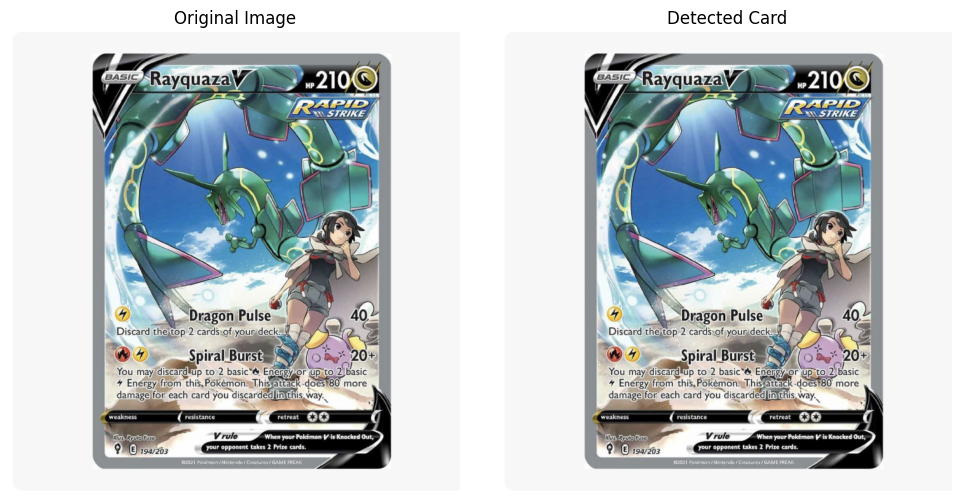

Detection successful!
Bounding box (x, y, width, height): (0, 0, 708, 724)
Card dimensions: 708 x 724 pixels


True

In [32]:
test_basic_detection()